In [12]:
import os
import numpy as np
import random
from shutil import copyfile, rmtree
from tqdm import tqdm
import time

import tensorflow as tf
from tensorflow.keras import Model, layers, callbacks
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# ==================== CONFIG ====================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 60
INITIAL_LR = 5e-5
LABEL_SMOOTHING = 0.1
train_ratio, val_ratio = 0.7, 0.15

dataset_dir = '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9'
base_dir = '/kaggle/working/colon_split'

# ==================== CLEAR OLD SPLIT ====================
if os.path.exists(base_dir):
    rmtree(base_dir)

# ==================== SPLIT DATA ====================
splits = ['train', 'val', 'test']
class_names = os.listdir(dataset_dir)

for split in splits:
    for class_name in class_names:
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

for class_name in class_names:
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    random.shuffle(image_list)
    n_total = len(image_list)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)

    train_files = image_list[:n_train]
    val_files = image_list[n_train:n_train + n_val]
    test_files = image_list[n_train + n_val:]

    for split, split_files in zip(['train', 'val', 'test'], [train_files, val_files, test_files]):
        for img in tqdm(split_files, desc=f'{class_name} - {split}'):
            src = os.path.join(dataset_dir, class_name, img)
            dst = os.path.join(base_dir, split, class_name, img)
            copyfile(src, dst)

# ==================== DATA GENERATORS ====================
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_generator = datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
test_generator = datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)

# ==================== MODEL ====================
def build_convnexttiny_model():
    base_model = ConvNeXtTiny(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    # Reduced capacity with minimal regularization
    x = layers.Dense(2, activation='relu')(x)  # Reduced from 4 to 2 neurons
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inputs, outputs)

model = build_convnexttiny_model()

# ==================== COMPILE ====================
loss_fn = CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)
optimizer = Adam(learning_rate=INITIAL_LR)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

# ==================== PARAMETER COUNTS ====================
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])
print(f"\n📊 Trainable parameters: {trainable_params:,}")
print(f"📊 Non-trainable parameters: {non_trainable_params:,}")
print(f"📊 Total parameters: {trainable_params + non_trainable_params:,}\n")

# ==================== CALLBACKS ====================
checkpoint_cb = callbacks.ModelCheckpoint(
    'convnexttiny.keras', monitor='val_loss', save_best_only=True, verbose=1
)
# Reduced early stopping patience to allow slight overfitting
earlystop_cb = callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True  
)
reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-7  
)

# ==================== TRAIN ====================
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb],
    verbose=1
)

end_time = time.time()
total_time = end_time - start_time
avg_epoch_time = total_time / len(history.history['loss'])

print(f"\n⏱️ Total Training Time: {total_time:.2f} seconds")
print(f"⏱️ Average Time per Epoch: {avg_epoch_time:.2f} seconds")

# ==================== EVALUATE ====================
model.load_weights("convnexttiny.keras")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

1_ulcerative_colitis - test: 100%|██████████| 225/225 [00:00<00:00, 496.12it/s]


Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.

📊 Trainable parameters: 1,550
📊 Non-trainable parameters: 27,820,128
📊 Total parameters: 27,821,678

Epoch 1/60


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.2367 - loss: 1.3681
Epoch 1: val_loss improved from inf to 1.33150, saving model to convnexttiny.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 48s 240ms/step - accuracy: 0.2368 - loss: 1.3680 - val_accuracy: 0.3089 - val_loss: 1.3315 - learning_rate: 5.0000e-05
Epoch 2/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.2749 - loss: 1.3229
Epoch 2: val_loss improved from 1.33150 to 1.28877, saving model to convnexttiny.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 22s 168ms/step - accuracy: 0.2750 - loss: 1.3228 - val_accuracy: 0.3356 - val_loss: 1.2888 - learning_rate: 5.0000e-05
Epoch 3/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.3215 - loss: 1.2819
Epoch 3: val_loss improved from 1.28877 to 1.25011, saving model to convnexttiny.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 23s 171ms/step - accuracy: 0.3216 - loss: 1.2818 - val_accuracy: 0.3556 - val_loss: 1.2501 - learning_rate: 5.0000e-05
Epoch 4/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 141

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step


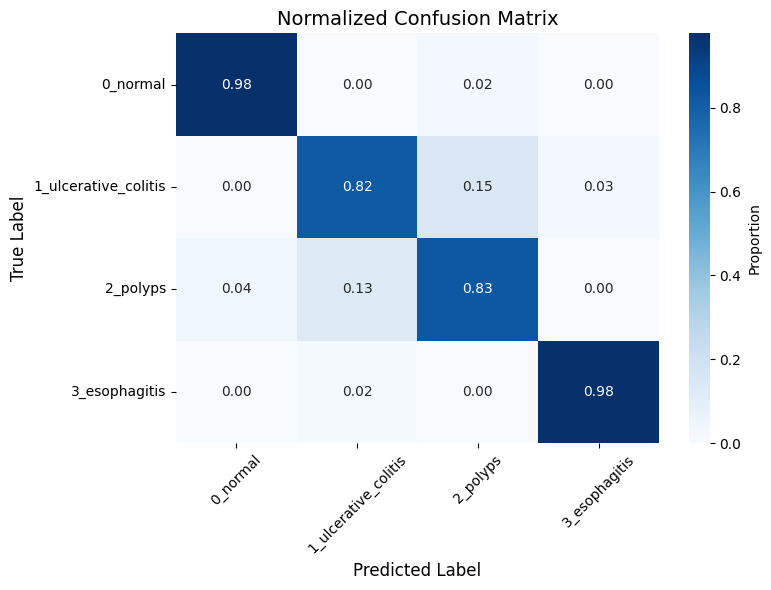

Classification Report:
                      precision    recall  f1-score   support

            0_normal       0.96      0.98      0.97       225
1_ulcerative_colitis       0.84      0.82      0.83       225
            2_polyps       0.82      0.83      0.82       225
       3_esophagitis       0.97      0.98      0.98       225

            accuracy                           0.90       900
           macro avg       0.90      0.90      0.90       900
        weighted avg       0.90      0.90      0.90       900



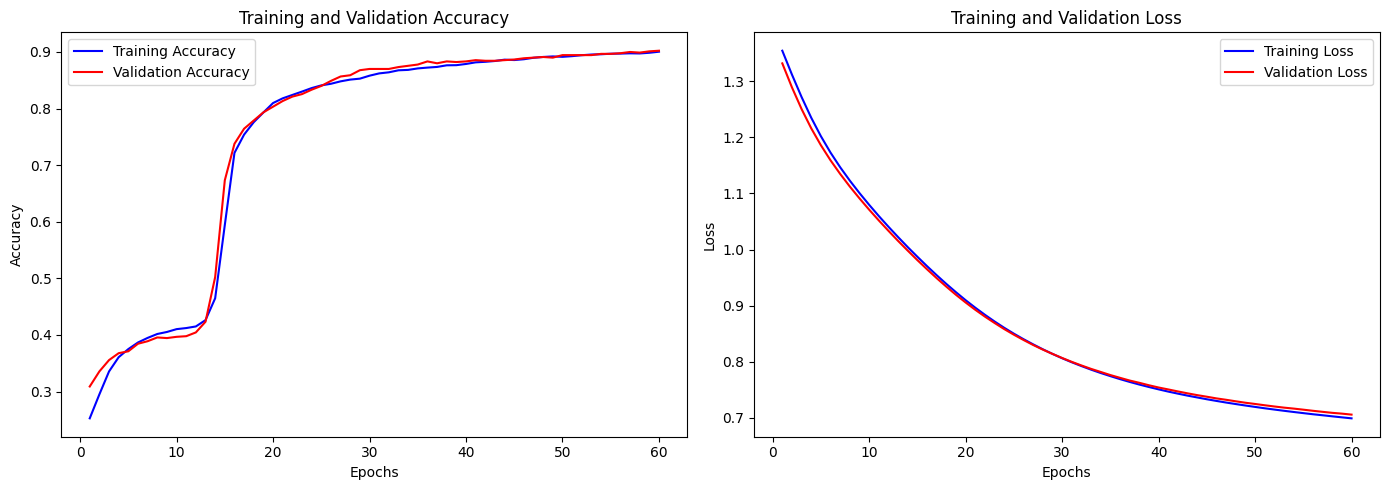

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get true labels and predictions
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class labels
class_labels = list(test_generator.class_indices.keys())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize by row
class_labels = list(test_generator.class_indices.keys())

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Proportion'})

plt.title("Normalized Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============ CLASSIFICATION REPORT ============
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# ============ ACCURACY & LOSS CURVES ============
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)